In [1]:
import pandas as pd
import numpy as np
import torch.nn as nn
import torch
import matplotlib.pyplot as plt
import sys
import os
from pathlib import Path
from collections import deque

In [2]:
current_dir = Path.cwd()
insert_dir = os.path.join(current_dir , '..' , 'models-architecture');
sys.path.insert(0 ,insert_dir)

In [3]:
from ncf import NeuralCollaborativeFramework

In [ ]:
rname = ['user_id' , 'movie_id', 'rating','timestamp']
# ratings_df = pd.read_csv('../../data/mv-lens-1m/ratings.dat', delimiter = '::',header=None, engine='python' , names=rname)
# 32M Dataset
ratings_df = pd.read_csv('../../data/mv-lens-32m/ml-32m/ratings.csv')
ratings_df.rename(columns={"userId" : "user_id" , "movieId":"movie_id"} , inplace=True)
    
ratings_df.head()

,user_id,movie_id,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858


In [12]:
num_users = ratings_df['user_id'].nunique()
num_movies = ratings_df['movie_id'].nunique()

print(num_users , num_movies)

200948 84432


In [13]:
model = NeuralCollaborativeFramework(num_users , num_movies , dropout_rate=0.2 ,hidden_layers=(64, 64, 32, 16, 8, 4))
print(f"ncf model architecture {model}")

ncf model architecture NeuralCollaborativeFramework(
  (user_embedding): Embedding(200948, 32)
  (movie_embedding): Embedding(84432, 32)
  (MLP): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=16, out_features=8, bias=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=8, out_features=4, bias=True)
    (13): ReLU()
    (14): Dropout(p=0.2, inplace=False)
    (15): Linear(in_features=4, out_features=1, bias=True)
    (16): Sigmoid()
  )
  (dropout): Dropout(p=0.2, inplace=False)
)


In [14]:
from torch.utils.data import Dataset, DataLoader

# Prepare data tensors (convert user and movie ids to zero-based indices)
user_ids = torch.tensor(ratings_df['user_id'].values - 1, dtype=torch.long)
movie_ids = torch.tensor(ratings_df['movie_id'].values - 1, dtype=torch.long)


ratings = torch.tensor(ratings_df['rating'].values.astype(np.float32), dtype=torch.float32)

num_samples = len(ratings)
indices = torch.randperm(num_samples)
split = int(0.8 * num_samples)

train_indices = indices[:split]
val_indices = indices[split:]


class RatingsDataset(Dataset):
    def __init__(self, user_ids, movie_ids, ratings, indices):
        self.user_ids = user_ids[indices]
        self.movie_ids = movie_ids[indices]
        self.ratings = ratings[indices]

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return (
            self.user_ids[idx],
            self.movie_ids[idx],
            self.ratings[idx],
        )

train_dataset = RatingsDataset(user_ids, movie_ids, ratings, train_indices)
val_dataset = RatingsDataset(user_ids, movie_ids, ratings, val_indices)
batch_size = 1024

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


movie_batch, user_batch, rating_batch = next(iter(train_loader))


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)

num_epochs = 40
patience = 5
min_delta = 5e-4
overfit_gap_threshold = 0.02
underfit_window = 6
underfit_tolerance = 5e-4
underfit_rmse_floor = 0.9

history = {"train_rmse": [], "val_rmse": [], "lr": []}
recent_train = deque(maxlen=underfit_window)
recent_val = deque(maxlen=underfit_window)
best_val_rmse = float("inf")
best_epoch = 0
best_model_state = None
epochs_since_improve = 0
early_stop_reason = None
last_epoch = 0

for epoch in range(1, num_epochs + 1):
    model.train()
    train_squared_loss = 0.0

    for batch_user, batch_movie, batch_rating in train_loader:
        batch_user = batch_user.to(device)
        batch_movie = batch_movie.to(device)
        batch_rating = batch_rating.to(device)

        optimizer.zero_grad()
        outputs = model(batch_user, batch_movie).squeeze()
        loss = criterion(outputs, batch_rating)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        train_squared_loss += loss.item() * batch_rating.size(0)

    train_mse = train_squared_loss / len(train_loader.dataset)
    train_rmse = train_mse ** 0.5

    model.eval()
    val_squared_loss = 0.0

    with torch.no_grad():
        for batch_user, batch_movie, batch_rating in val_loader:
            batch_user = batch_user.to(device)
            batch_movie = batch_movie.to(device)
            batch_rating = batch_rating.to(device)

            outputs = model(batch_user, batch_movie).squeeze()
            loss = criterion(outputs, batch_rating)

            val_squared_loss += loss.item() * batch_rating.size(0)

    val_mse = val_squared_loss / len(val_loader.dataset)
    val_rmse = val_mse ** 0.5

    scheduler.step(val_rmse)

    history["train_rmse"].append(train_rmse)
    history["val_rmse"].append(val_rmse)
    history["lr"].append(optimizer.param_groups[0]["lr"])
    recent_train.append(train_rmse)
    recent_val.append(val_rmse)
    last_epoch = epoch

    if val_rmse + min_delta < best_val_rmse:
        best_val_rmse = val_rmse
        best_epoch = epoch
        best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_since_improve = 0
    else:
        epochs_since_improve += 1

    overfit_gap = val_rmse - train_rmse
    if overfit_gap > overfit_gap_threshold and epochs_since_improve >= 2:
        early_stop_reason = (
            f"overfitting suspected (val-train gap {overfit_gap:.4f} > {overfit_gap_threshold})"
        )
    elif epochs_since_improve >= patience:
        early_stop_reason = f"no validation improvement for {patience} epochs"

    if (
        len(recent_train) == underfit_window
        and max(recent_train) - min(recent_train) < underfit_tolerance
        and max(recent_val) - min(recent_val) < underfit_tolerance
        and min(recent_train) > underfit_rmse_floor
        and min(recent_val) > underfit_rmse_floor
    ):
        early_stop_reason = (
            f"underfitting suspected (RMSE plateaued above {underfit_rmse_floor})"
        )

    print(
        f"Epoch {epoch}/{num_epochs} - Train RMSE: {train_rmse:.4f} - Val RMSE: {val_rmse:.4f}"
        f" - LR: {history['lr'][-1]:.2e}"
    )

    if early_stop_reason:
        print(f"Early stopping triggered: {early_stop_reason}")
        break

if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(
        f"Restored weights from epoch {best_epoch} with best Val RMSE: {best_val_rmse:.4f}"
    )

if not early_stop_reason:
    print("Training completed all epochs without triggering early stopping.")
else:
    print(f"Stopped after {last_epoch} epochs due to: {early_stop_reason}")


Epoch 1/40 - Train RMSE: 0.9041 - Val RMSE: 0.8649 - LR: 1.00e-03
Epoch 2/40 - Train RMSE: 0.8911 - Val RMSE: 0.8595 - LR: 1.00e-03
Epoch 3/40 - Train RMSE: 0.8898 - Val RMSE: 0.8598 - LR: 1.00e-03


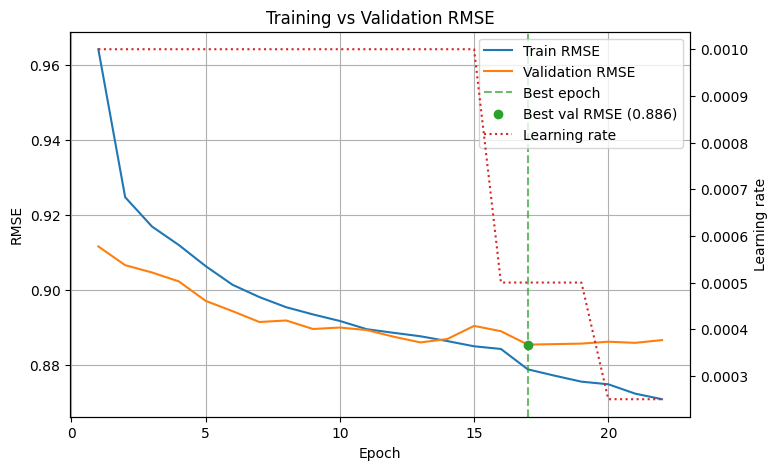

Final Train RMSE: 0.8710
Final Val RMSE: 0.8867
Best Val RMSE (0.8855) reached at epoch 17
Training stopped early because no validation improvement for 5 epochs


In [10]:
epochs = range(1, len(history["train_rmse"]) + 1)

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(epochs, history["train_rmse"], label="Train RMSE", color="tab:blue")
ax1.plot(epochs, history["val_rmse"], label="Validation RMSE", color="tab:orange")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("RMSE")
ax1.set_title("Training vs Validation RMSE")
ax1.grid(True)

if best_epoch:
    ax1.axvline(best_epoch, color="tab:green", linestyle="--", alpha=0.7, label="Best epoch")
    ax1.scatter(
        best_epoch,
        best_val_rmse,
        color="tab:green",
        zorder=5,
        label=f"Best val RMSE ({best_val_rmse:.3f})"
    )

ax2 = ax1.twinx()
ax2.plot(epochs, history["lr"], color="tab:red", linestyle=":", label="Learning rate")
ax2.set_ylabel("Learning rate")

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper right")
plt.show()

print(f"Final Train RMSE: {history['train_rmse'][-1]:.4f}")
print(f"Final Val RMSE: {history['val_rmse'][-1]:.4f}")
print(f"Best Val RMSE ({best_val_rmse:.4f}) reached at epoch {best_epoch}")
if early_stop_reason:
    print(f"Training stopped early because {early_stop_reason}")
else:
    print("Training completed full schedule without early stop")


# Early stopping + regularization heuristics keep overfitting in check

In [11]:
# Baseline: predict global mean rating (computed on train set) and evaluate on validation set

# ratings is a 1D tensor of all ratings; train_indices and val_indices were defined earlier
train_global_mean = ratings[train_indices].mean().item()
val_targets = ratings[val_indices]
val_preds = torch.full_like(val_targets, train_global_mean)

baseline_mse = torch.mean((val_preds - val_targets) ** 2).item()
baseline_rmse = baseline_mse ** 0.5

print(f"Global-mean baseline (train set mean): {train_global_mean:.4f}")
print(f"Global-mean baseline Val RMSE: {baseline_rmse:.4f}")


Global-mean baseline (train set mean): 3.5805
Global-mean baseline Val RMSE: 1.1181
